In [1]:
# Install the required libraries
%pip install -q hazm lime openpyxl

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 19.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 887.2/887.2 kB 42.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 55.8 MB/s eta 0:00:00


In [2]:
import re
import string
import warnings

import hazm
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [37]:
df=pd.read_csv('/content/drive/MyDrive/datasets/persian_suicide.csv')

In [38]:
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (198055, 2)

Column names:
['Text', 'Class']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198055 entries, 0 to 198054
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   Text    197271 non-null  object
 1   Class   197279 non-null  object
dtypes: object(2)
memory usage: 3.0+ MB

Missing values:
Text     784
Class    776
dtype: int64


In [39]:
# Remove rows with missing text or class labels
df = df.dropna(subset=["Text", "Class"]).copy()

# Reset row indices
df.reset_index(drop=True, inplace=True)

print("Dataset shape after removing missing values:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

Dataset shape after removing missing values: (197270, 2)

Missing values:
Text     0
Class    0
dtype: int64


In [40]:
# Remove extra spaces from class labels
df["Class"] = df["Class"].str.strip()

# Map text labels to numerical labels
label_mapping = {
    "خودکشی کردن": 0,
    "غیر خودکشی": 1
}

df["Class"] = df["Class"].map(label_mapping)

# Display the class distribution after mapping
print(df["Class"].value_counts().sort_index())

print("\nMissing labels after mapping:")
print(df["Class"].isnull().sum())

Class
0    98669
1    98601
Name: count, dtype: int64

Missing labels after mapping:
0


In [18]:
stopwords = set(hazm.stopwords_list())

# Convert Arabic characters to their Persian equivalents
character_mapping = str.maketrans({
    "ي": "ی",
    "ى": "ی",
    "ك": "ک",
    "ؤ": "و",
    "إ": "ا",
    "أ": "ا",
    "ة": "ه",
    "ۀ": "ه"
})

# Compile patterns once for better performance
url_pattern = re.compile(r"https?://\S+|www\.\S+")
username_pattern = re.compile(r"@\w+")
english_pattern = re.compile(r"[A-Za-z]+")
number_pattern = re.compile(r"[0-9۰-۹]+")
non_persian_pattern = re.compile(r"[^آ-ی\s‌]")
space_pattern = re.compile(r"\s+")


def fast_preprocess_text(text):
    """Fast preprocessing without tokenization and lemmatization."""

    text = str(text)

    # Normalize Arabic/Persian characters
    text = text.translate(character_mapping)

    # Remove URLs, usernames, English words and numbers
    text = url_pattern.sub(" ", text)
    text = username_pattern.sub(" ", text)
    text = english_pattern.sub(" ", text)
    text = number_pattern.sub(" ", text)

    # Remove punctuation, emojis and other characters
    text = non_persian_pattern.sub(" ", text)

    # Tokenize using split, which is much faster than Hazm word_tokenize
    tokens = text.split()

    # Remove stopwords
    tokens = [
        token
        for token in tokens
        if token not in stopwords
    ]

    # Join tokens and remove extra spaces
    text = " ".join(tokens)
    text = space_pattern.sub(" ", text).strip()

    return text

In [19]:
from google.colab import drive
from pathlib import Path

# Mount Google Drive
drive.mount("/content/drive")

# Create a folder for checkpoints and final outputs
SAVE_DIR = Path("/content/drive/MyDrive/Persian_Suicide_Project")
CHECKPOINT_DIR = SAVE_DIR / "preprocessing_checkpoints"

SAVE_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

print("Files will be saved in:")
print(SAVE_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Files will be saved in:
/content/drive/MyDrive/Persian_Suicide_Project


In [21]:
import time

start_time = time.time()

# Create a copy of the dataset
processed_df = df.copy()

# Preprocess all texts
processed_df["Processed_Text"] = processed_df["Text"].apply(
    fast_preprocess_text
)

# Save immediately to Google Drive
PREPROCESSED_FILE = SAVE_DIR / "persian_suicide_preprocessed.csv"

processed_df.to_csv(
    PREPROCESSED_FILE,
    index=False,
    encoding="utf-8-sig"
)

elapsed_time = time.time() - start_time

print(f"Preprocessing completed in {elapsed_time:.2f} seconds.")
print(f"Dataset shape: {processed_df.shape}")
print(f"Saved successfully to:\n{PREPROCESSED_FILE}")

Preprocessing completed in 57.42 seconds.
Dataset shape: (197270, 3)
Saved successfully to:
/content/drive/MyDrive/Persian_Suicide_Project/persian_suicide_preprocessed.csv


In [22]:
# Count empty processed texts
empty_mask = (
    processed_df["Processed_Text"].isna()
    | processed_df["Processed_Text"].str.strip().eq("")
)

empty_count = empty_mask.sum()

# Count duplicated processed texts
duplicate_count = processed_df.duplicated(
    subset=["Processed_Text"],
    keep=False
).sum()

# Find processed texts associated with both classes
label_conflicts = (
    processed_df.loc[~empty_mask]
    .groupby("Processed_Text")["Class"]
    .nunique()
)

conflicting_text_count = (label_conflicts > 1).sum()

print(f"Empty processed texts: {empty_count:,}")
print(f"Rows belonging to duplicated texts: {duplicate_count:,}")
print(f"Texts with conflicting labels: {conflicting_text_count:,}")

Empty processed texts: 415
Rows belonging to duplicated texts: 1,349
Texts with conflicting labels: 30


In [23]:
# Start from the complete preprocessed dataset
clean_df = processed_df.copy()

initial_count = len(clean_df)

# 1. Remove empty processed texts
clean_df = clean_df[
    clean_df["Processed_Text"].notna()
    & clean_df["Processed_Text"].str.strip().ne("")
].copy()

after_empty_removal = len(clean_df)

# 2. Identify texts associated with more than one class
conflicting_texts = (
    clean_df.groupby("Processed_Text")["Class"]
    .nunique()
)

conflicting_texts = conflicting_texts[
    conflicting_texts > 1
].index

# Remove every row associated with a conflicting text
clean_df = clean_df[
    ~clean_df["Processed_Text"].isin(conflicting_texts)
].copy()

after_conflict_removal = len(clean_df)

# 3. Keep only one copy of each remaining processed text
clean_df = clean_df.drop_duplicates(
    subset=["Processed_Text"],
    keep="first"
)

# Reset indices and ensure integer labels
clean_df.reset_index(drop=True, inplace=True)
clean_df["Class"] = clean_df["Class"].astype(int)

# Save the cleaned dataset
CLEAN_FILE = SAVE_DIR / "persian_suicide_cleaned.csv"

clean_df.to_csv(
    CLEAN_FILE,
    index=False,
    encoding="utf-8-sig"
)

print(f"Initial rows: {initial_count:,}")
print(f"Removed empty rows: {initial_count - after_empty_removal:,}")
print(
    f"Removed rows with conflicting labels: "
    f"{after_empty_removal - after_conflict_removal:,}"
)
print(
    f"Removed remaining duplicate rows: "
    f"{after_conflict_removal - len(clean_df):,}"
)
print(f"Final rows: {len(clean_df):,}")

print("\nFinal class distribution:")
print(clean_df["Class"].value_counts().sort_index())

print(f"\nCleaned dataset saved to:\n{CLEAN_FILE}")

Initial rows: 197,270
Removed empty rows: 415
Removed rows with conflicting labels: 101
Removed remaining duplicate rows: 528
Final rows: 196,226

Final class distribution:
Class
0    98505
1    97721
Name: count, dtype: int64

Cleaned dataset saved to:
/content/drive/MyDrive/Persian_Suicide_Project/persian_suicide_cleaned.csv


In [24]:
# Calculate text length based on the number of words
clean_df["Text_Length"] = clean_df["Processed_Text"].str.split().str.len()

print("Text length statistics:")
print(
    clean_df["Text_Length"]
    .describe(percentiles=[0.01, 0.05, 0.50, 0.95, 0.99])
)

print("\nPotential filtering counts:")
print(f"Texts with 3 words or fewer: {(clean_df['Text_Length'] <= 3).sum():,}")
print(f"Texts longer than 280 words: {(clean_df['Text_Length'] > 280).sum():,}")

within_range = clean_df["Text_Length"].between(
    4,
    280,
    inclusive="both"
).mean() * 100

print(f"Texts containing 4 to 280 words: {within_range:.2f}%")

Text length statistics:
count    196226.000000
mean         60.062387
std          93.421931
min           1.000000
1%            3.000000
5%            5.000000
50%          28.000000
95%         214.000000
99%         430.000000
max        3307.000000
Name: Text_Length, dtype: float64

Potential filtering counts:
Texts with 3 words or fewer: 4,243
Texts longer than 280 words: 5,574
Texts containing 4 to 280 words: 95.00%


In [25]:
# Keep texts containing 4 to 280 words
final_df = clean_df[
    clean_df["Text_Length"].between(
        4,
        280,
        inclusive="both"
    )
].copy()

final_df.reset_index(drop=True, inplace=True)

# Save the final dataset for modeling
FINAL_DATA_FILE = SAVE_DIR / "persian_suicide_final.csv"

final_df.to_csv(
    FINAL_DATA_FILE,
    index=False,
    encoding="utf-8-sig"
)

print(f"Rows before length filtering: {len(clean_df):,}")
print(f"Rows removed by length filtering: {len(clean_df) - len(final_df):,}")
print(f"Final dataset rows: {len(final_df):,}")

print("\nFinal class distribution:")
print(final_df["Class"].value_counts().sort_index())

print("\nFinal class percentages:")
print(
    final_df["Class"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

print(f"\nFinal dataset saved to:\n{FINAL_DATA_FILE}")

Rows before length filtering: 196,226
Rows removed by length filtering: 9,817
Final dataset rows: 186,409

Final class distribution:
Class
0    92668
1    93741
Name: count, dtype: int64

Final class percentages:
Class
0    49.71
1    50.29
Name: proportion, dtype: float64

Final dataset saved to:
/content/drive/MyDrive/Persian_Suicide_Project/persian_suicide_final.csv


Modeling

In [26]:
from sklearn.model_selection import train_test_split

# Features and target
X = final_df["Processed_Text"]
y = final_df["Class"]

# Stratified 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training samples: {len(X_train):,}")
print(f"Testing samples: {len(X_test):,}")

print("\nTraining class distribution:")
print(y_train.value_counts().sort_index())

print("\nTesting class distribution:")
print(y_test.value_counts().sort_index())

Training samples: 149,127
Testing samples: 37,282

Training class distribution:
Class
0    74134
1    74993
Name: count, dtype: int64

Testing class distribution:
Class
0    18534
1    18748
Name: count, dtype: int64


In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 3),
    sublinear_tf=True,
    dtype=np.float32
)

# Learn vocabulary and IDF only from training data
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

# Transform test data using the fitted vectorizer
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("TF-IDF completed successfully.")
print(f"Training matrix shape: {X_train_tfidf.shape}")
print(f"Testing matrix shape: {X_test_tfidf.shape}")
print(f"Vocabulary size: {len(tfidf_vectorizer.vocabulary_):,}")

TF-IDF completed successfully.
Training matrix shape: (149127, 10000)
Testing matrix shape: (37282, 10000)
Vocabulary size: 10,000


In [28]:
import joblib
from scipy.sparse import save_npz

# Define artifact paths
VECTORIZER_FILE = SAVE_DIR / "tfidf_vectorizer.joblib"
X_TRAIN_FILE = SAVE_DIR / "X_train_tfidf.npz"
X_TEST_FILE = SAVE_DIR / "X_test_tfidf.npz"
Y_TRAIN_FILE = SAVE_DIR / "y_train.npy"
Y_TEST_FILE = SAVE_DIR / "y_test.npy"

# Save the fitted TF-IDF vectorizer
joblib.dump(tfidf_vectorizer, VECTORIZER_FILE)

# Save sparse TF-IDF matrices
save_npz(X_TRAIN_FILE, X_train_tfidf)
save_npz(X_TEST_FILE, X_test_tfidf)

# Save labels
np.save(Y_TRAIN_FILE, y_train.to_numpy())
np.save(Y_TEST_FILE, y_test.to_numpy())

print("TF-IDF artifacts saved successfully:")
print(VECTORIZER_FILE)
print(X_TRAIN_FILE)
print(X_TEST_FILE)
print(Y_TRAIN_FILE)
print(Y_TEST_FILE)

TF-IDF artifacts saved successfully:
/content/drive/MyDrive/Persian_Suicide_Project/tfidf_vectorizer.joblib
/content/drive/MyDrive/Persian_Suicide_Project/X_train_tfidf.npz
/content/drive/MyDrive/Persian_Suicide_Project/X_test_tfidf.npz
/content/drive/MyDrive/Persian_Suicide_Project/y_train.npy
/content/drive/MyDrive/Persian_Suicide_Project/y_test.npy


In [29]:
import time
from sklearn.svm import LinearSVC

# Initialize the model
svm_model = LinearSVC(
    C=1.0,
    max_iter=5000,
    random_state=42
)

# Train the model
start_time = time.time()

svm_model.fit(X_train_tfidf, y_train)

training_time = time.time() - start_time

# Save the trained model
MODEL_FILE = SAVE_DIR / "linear_svm_model.joblib"
joblib.dump(svm_model, MODEL_FILE)

print(f"Model training completed in {training_time:.2f} seconds.")
print(f"Number of iterations: {svm_model.n_iter_}")
print(f"Model saved to:\n{MODEL_FILE}")

Model training completed in 4.08 seconds.
Number of iterations: 8
Model saved to:
/content/drive/MyDrive/Persian_Suicide_Project/linear_svm_model.joblib


In [30]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Predict test labels
y_pred = svm_model.predict(X_test_tfidf)

# Calculate overall metrics
accuracy = accuracy_score(y_test, y_pred)
balanced_accuracy = balanced_accuracy_score(y_test, y_pred)

# Calculate suicide-class metrics explicitly using pos_label=0
suicide_precision = precision_score(
    y_test,
    y_pred,
    pos_label=0
)

suicide_recall = recall_score(
    y_test,
    y_pred,
    pos_label=0
)

suicide_f1 = f1_score(
    y_test,
    y_pred,
    pos_label=0
)

print(f"Accuracy:          {accuracy:.4f}")
print(f"Balanced Accuracy: {balanced_accuracy:.4f}")
print(f"Suicide Precision: {suicide_precision:.4f}")
print(f"Suicide Recall:    {suicide_recall:.4f}")
print(f"Suicide F1-score:  {suicide_f1:.4f}")

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        labels=[0, 1],
        target_names=["Suicide", "Non-suicide"],
        digits=4
    )
)

Accuracy:          0.9255
Balanced Accuracy: 0.9254
Suicide Precision: 0.9321
Suicide Recall:    0.9169
Suicide F1-score:  0.9244

Classification Report:

              precision    recall  f1-score   support

     Suicide     0.9321    0.9169    0.9244     18534
 Non-suicide     0.9192    0.9340    0.9265     18748

    accuracy                         0.9255     37282
   macro avg     0.9256    0.9254    0.9255     37282
weighted avg     0.9256    0.9255    0.9255     37282



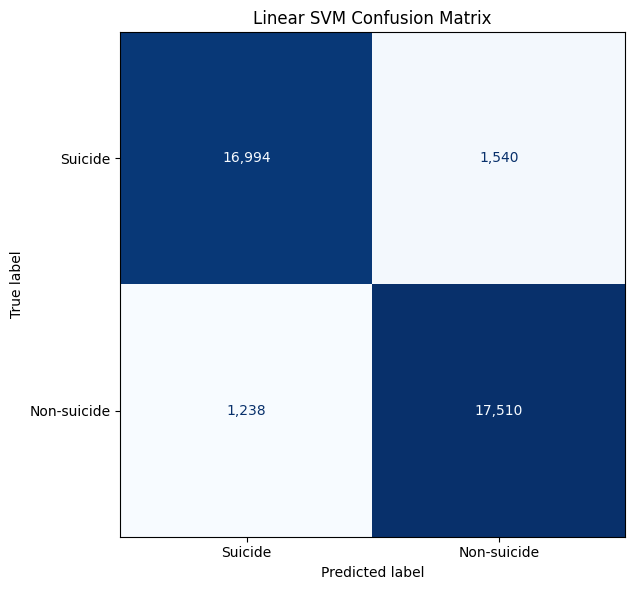

Confusion matrix saved to:
/content/drive/MyDrive/Persian_Suicide_Project/linear_svm_confusion_matrix.png


In [31]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(7, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    labels=[0, 1],
    display_labels=["Suicide", "Non-suicide"],
    cmap="Blues",
    values_format=",d",
    colorbar=False,
    ax=ax
)

ax.set_title("Linear SVM Confusion Matrix")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

plt.tight_layout()

# Save the figure
CONFUSION_MATRIX_FILE = SAVE_DIR / "linear_svm_confusion_matrix.png"

plt.savefig(
    CONFUSION_MATRIX_FILE,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Confusion matrix saved to:\n{CONFUSION_MATRIX_FILE}")

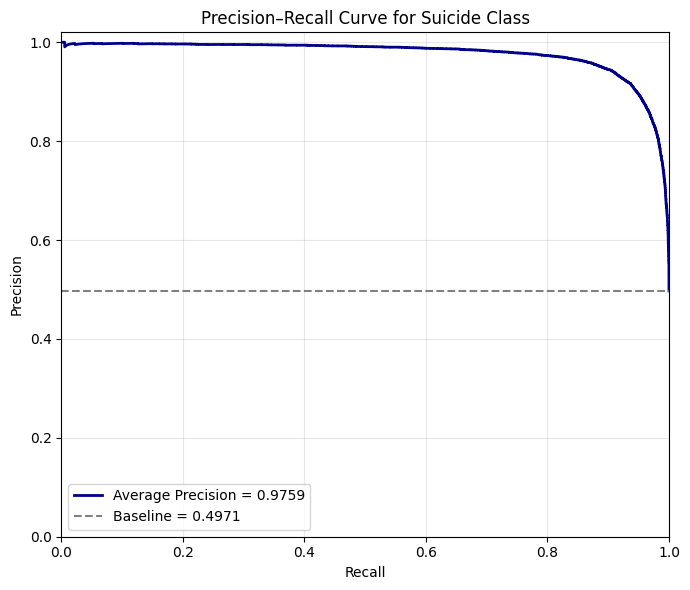

Average Precision: 0.9759
PR curve saved to:
/content/drive/MyDrive/Persian_Suicide_Project/linear_svm_precision_recall_curve.png


In [32]:
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score
)

# Convert suicide class to positive class
y_test_suicide = (y_test.to_numpy() == 0).astype(int)

# LinearSVC decision scores are positive for Class 1,
# so reverse them to obtain suicide scores
suicide_scores = -svm_model.decision_function(X_test_tfidf)

# Calculate Precision-Recall values
precision_values, recall_values, thresholds = precision_recall_curve(
    y_test_suicide,
    suicide_scores
)

average_precision = average_precision_score(
    y_test_suicide,
    suicide_scores
)

# Plot Precision-Recall curve
fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(
    recall_values,
    precision_values,
    color="darkblue",
    linewidth=2,
    label=f"Average Precision = {average_precision:.4f}"
)

# Baseline equals the proportion of suicide samples
baseline = y_test_suicide.mean()

ax.axhline(
    baseline,
    color="gray",
    linestyle="--",
    label=f"Baseline = {baseline:.4f}"
)

ax.set_title("Precision–Recall Curve for Suicide Class")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.legend(loc="lower left")
ax.grid(alpha=0.3)

plt.tight_layout()

PR_CURVE_FILE = SAVE_DIR / "linear_svm_precision_recall_curve.png"

plt.savefig(
    PR_CURVE_FILE,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Average Precision: {average_precision:.4f}")
print(f"PR curve saved to:\n{PR_CURVE_FILE}")